<a href="https://colab.research.google.com/github/Sharayu7305/DocShield---Privacy-Risk-Auditor-and-Smart-Redactor/blob/main/UrbanMind_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Urban_Cognitive_Load_Productivity_Dataset.csv to Urban_Cognitive_Load_Productivity_Dataset (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import r2_score, mean_absolute_error, classification_report

from mpl_toolkits.mplot3d import Axes3D

sns.set(style="darkgrid")

In [ ]:
df = pd.read_csv("Urban_Cognitive_Load_Productivity_Dataset.csv")
df.head()

,Employee_ID,City_Pollution_Index,Daily_Screen_Time_Hours,Sleep_Hours,Commute_Time_Minutes,Work_Hours_Per_Day,Meetings_Per_Day,Physical_Activity_Minutes,Cognitive_Load_Score,Productivity_Score
0,1,77.450712,10.798711,5.689786,6.843849,7.704760,7,42.639866,18.312114,50.919884
1,2,67.926035,9.849267,6.326578,27.792300,8.953195,0,34.074284,9.617931,62.216138
2,3,79.715328,8.119261,5.549096,36.727889,9.027025,7,17.723515,32.489652,32.499169
3,4,92.845448,6.706126,6.130446,82.753753,9.708946,5,30.164217,31.843191,33.339109
4,5,66.487699,9.396447,4.227662,56.131062,6.949712,3,45.703841,18.930508,50.116412


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Employee_ID                1000 non-null   int64  
 1   City_Pollution_Index       1000 non-null   float64
 2   Daily_Screen_Time_Hours    1000 non-null   float64
 3   Sleep_Hours                1000 non-null   float64
 4   Commute_Time_Minutes       1000 non-null   float64
 5   Work_Hours_Per_Day         1000 non-null   float64
 6   Meetings_Per_Day           1000 non-null   int64  
 7   Physical_Activity_Minutes  1000 non-null   float64
 8   Cognitive_Load_Score       1000 non-null   float64
 9   Productivity_Score         1000 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 78.3 KB


,Employee_ID,City_Pollution_Index,Daily_Screen_Time_Hours,Sleep_Hours,Commute_Time_Minutes,Work_Hours_Per_Day,Meetings_Per_Day,Physical_Activity_Minutes,Cognitive_Load_Score,Productivity_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,70.289981,8.141672,6.505649,44.783369,8.929595,4.584000,30.450521,18.460805,50.726692
std,288.819436,14.688239,1.994909,1.174202,20.192857,1.478662,2.956973,14.512224,11.633714,15.115553
min,1.000000,21.380990,2.119223,3.000000,5.000000,5.000000,0.000000,0.000000,-19.462490,0.000000
25%,250.750000,60.286145,6.787517,5.722400,30.251591,7.976093,2.000000,20.251716,10.903082,40.568051
50%,500.500000,70.379509,8.126154,6.499699,45.003691,8.972637,5.000000,30.383126,18.173355,51.100172
75%,750.250000,79.719158,9.457764,7.293098,58.338908,9.958685,7.000000,40.430574,26.279422,60.546356
max,1000.000000,127.790972,14.386215,10.000000,109.861859,13.669365,9.000000,83.992002,57.502699,100.000000


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
City_Pollution_Index,0
Daily_Screen_Time_Hours,0
Sleep_Hours,0
Commute_Time_Minutes,0
Work_Hours_Per_Day,0
Meetings_Per_Day,0
Physical_Activity_Minutes,0
Cognitive_Load_Score,0
Productivity_Score,0


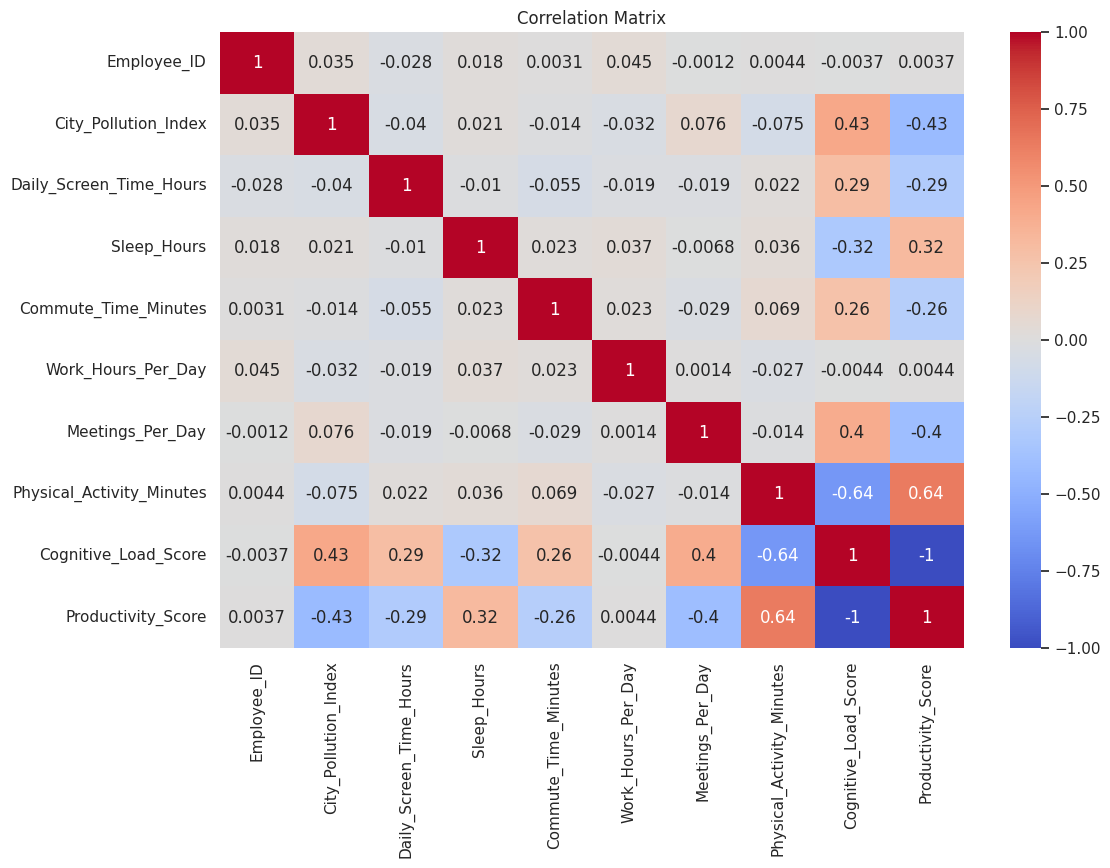

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df["Screen_Work_Interaction"] = (
    df["Daily_Screen_Time_Hours"] * df["Work_Hours_Per_Day"]
)

df["Sleep_Recovery_Ratio"] = (
    df["Sleep_Hours"] / df["Work_Hours_Per_Day"]
)

df["Stress_Balance_Index"] = (
    df["Physical_Activity_Minutes"] - df["Meetings_Per_Day"]
)

In [ ]:
df["Burnout_Binary"] = (
    df["Cognitive_Load_Score"] >
    df["Cognitive_Load_Score"].quantile(0.66)
).astype(int)

In [ ]:
X_burn = df[[
    "Daily_Screen_Time_Hours",
    "Sleep_Hours",
    "Meetings_Per_Day",
    "Commute_Time_Minutes"
]]

y_burn = df["Burnout_Binary"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_burn, y_burn, test_size=0.2, random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train_b, y_train_b)

df["Burnout_Probability"] = log_model.predict_proba(X_burn)[:,1]

print(classification_report(y_test_b, log_model.predict(X_test_b)))

              precision    recall  f1-score   support

           0       0.81      0.86      0.84       130
           1       0.71      0.63      0.67        70

    accuracy                           0.78       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.78      0.78      0.78       200



In [ ]:
X = df[[
    "City_Pollution_Index",
    "Daily_Screen_Time_Hours",
    "Sleep_Hours",
    "Commute_Time_Minutes",
    "Work_Hours_Per_Day",
    "Meetings_Per_Day",
    "Physical_Activity_Minutes",
    "Screen_Work_Interaction",
    "Sleep_Recovery_Ratio",
    "Stress_Balance_Index"
]]

y = df["Productivity_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

preds = gb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2 Score: 0.9547357930047016
MAE: 2.7706293828245516


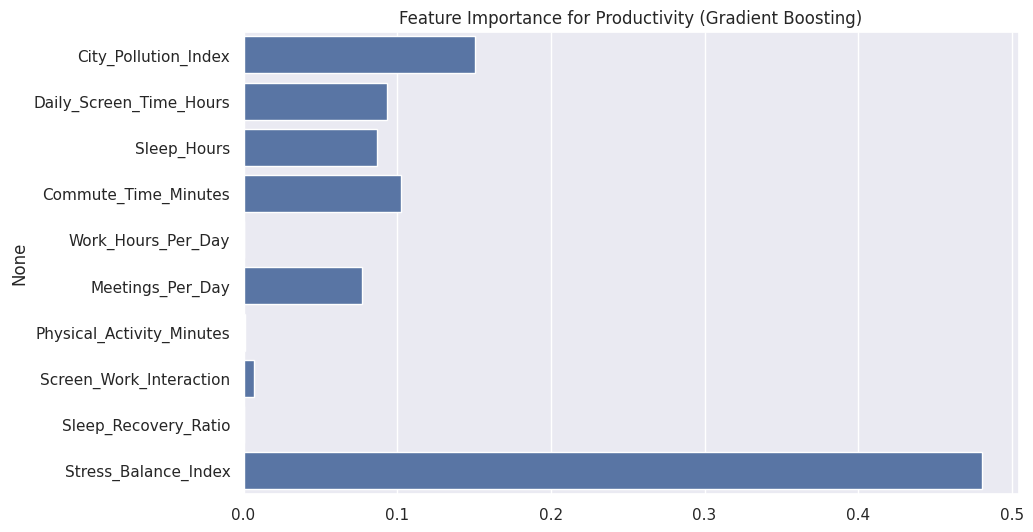

In [ ]:
importance = gb_model.feature_importances_

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance for Productivity (Gradient Boosting)")
plt.show()

In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

df["PCA1"] = components[:,0]
df["PCA2"] = components[:,1]

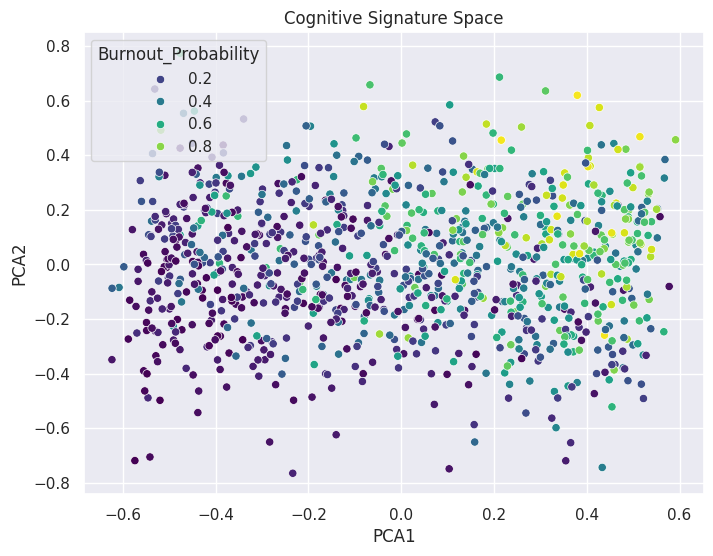

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Burnout_Probability",
    palette="viridis",
    data=df
)
plt.title("Cognitive Signature Space")
plt.show()

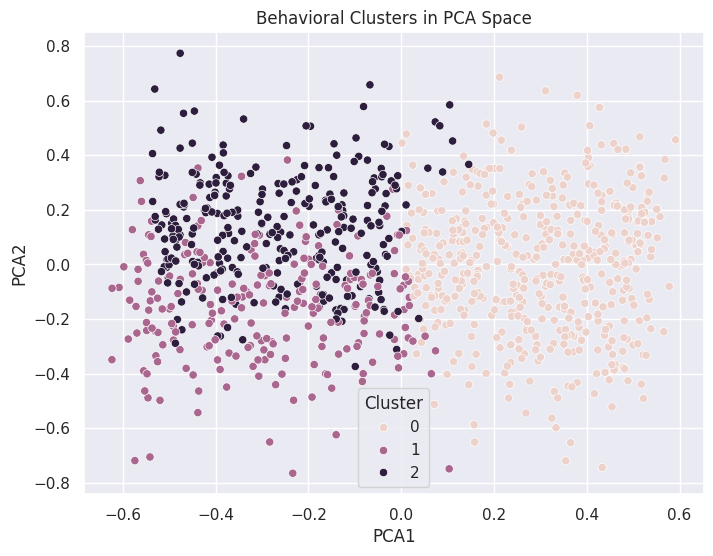

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df
)
plt.title("Behavioral Clusters in PCA Space")
plt.show()

In [ ]:
iso = IsolationForest(contamination=0.05, random_state=42)
df["Anomaly"] = iso.fit_predict(scaled)
df["Anomaly"] = df["Anomaly"].map({1:"Normal",-1:"Extreme Risk"})

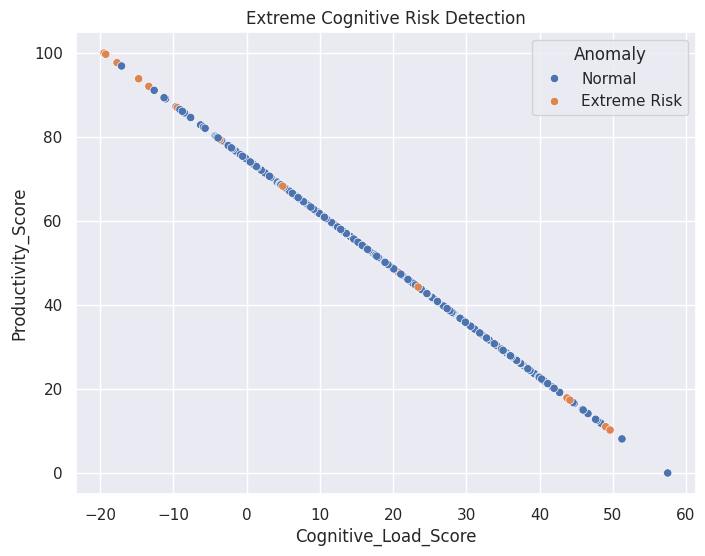

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Cognitive_Load_Score",
    y="Productivity_Score",
    hue="Anomaly",
    data=df
)
plt.title("Extreme Cognitive Risk Detection")
plt.show()

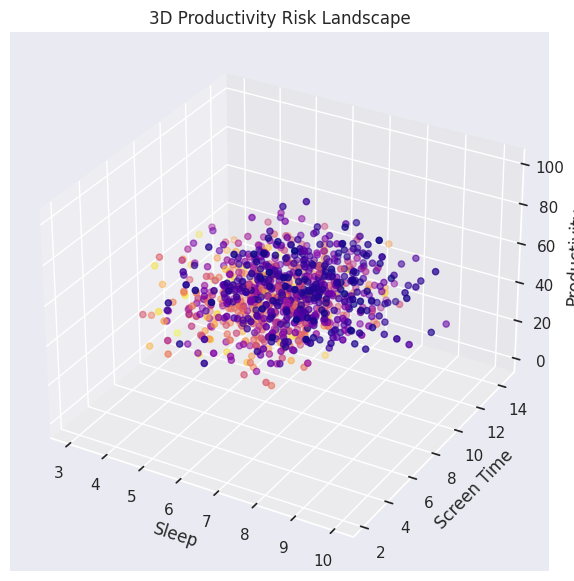

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Sleep_Hours"],
    df["Daily_Screen_Time_Hours"],
    df["Productivity_Score"],
    c=df["Burnout_Probability"],
    cmap="plasma"
)

ax.set_xlabel("Sleep")
ax.set_ylabel("Screen Time")
ax.set_zlabel("Productivity")
plt.title("3D Productivity Risk Landscape")
plt.show()

In [ ]:
df.to_csv("UrbanMind_Elite_Dashboard_Data.csv", index=False)

In [ ]:
files.download("UrbanMind_Elite_Dashboard_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>